In [ ]:
                                               # ------ STUDENT PEFORMANCE ----- #

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('Student_Performance.csv')

In [5]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [7]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [8]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


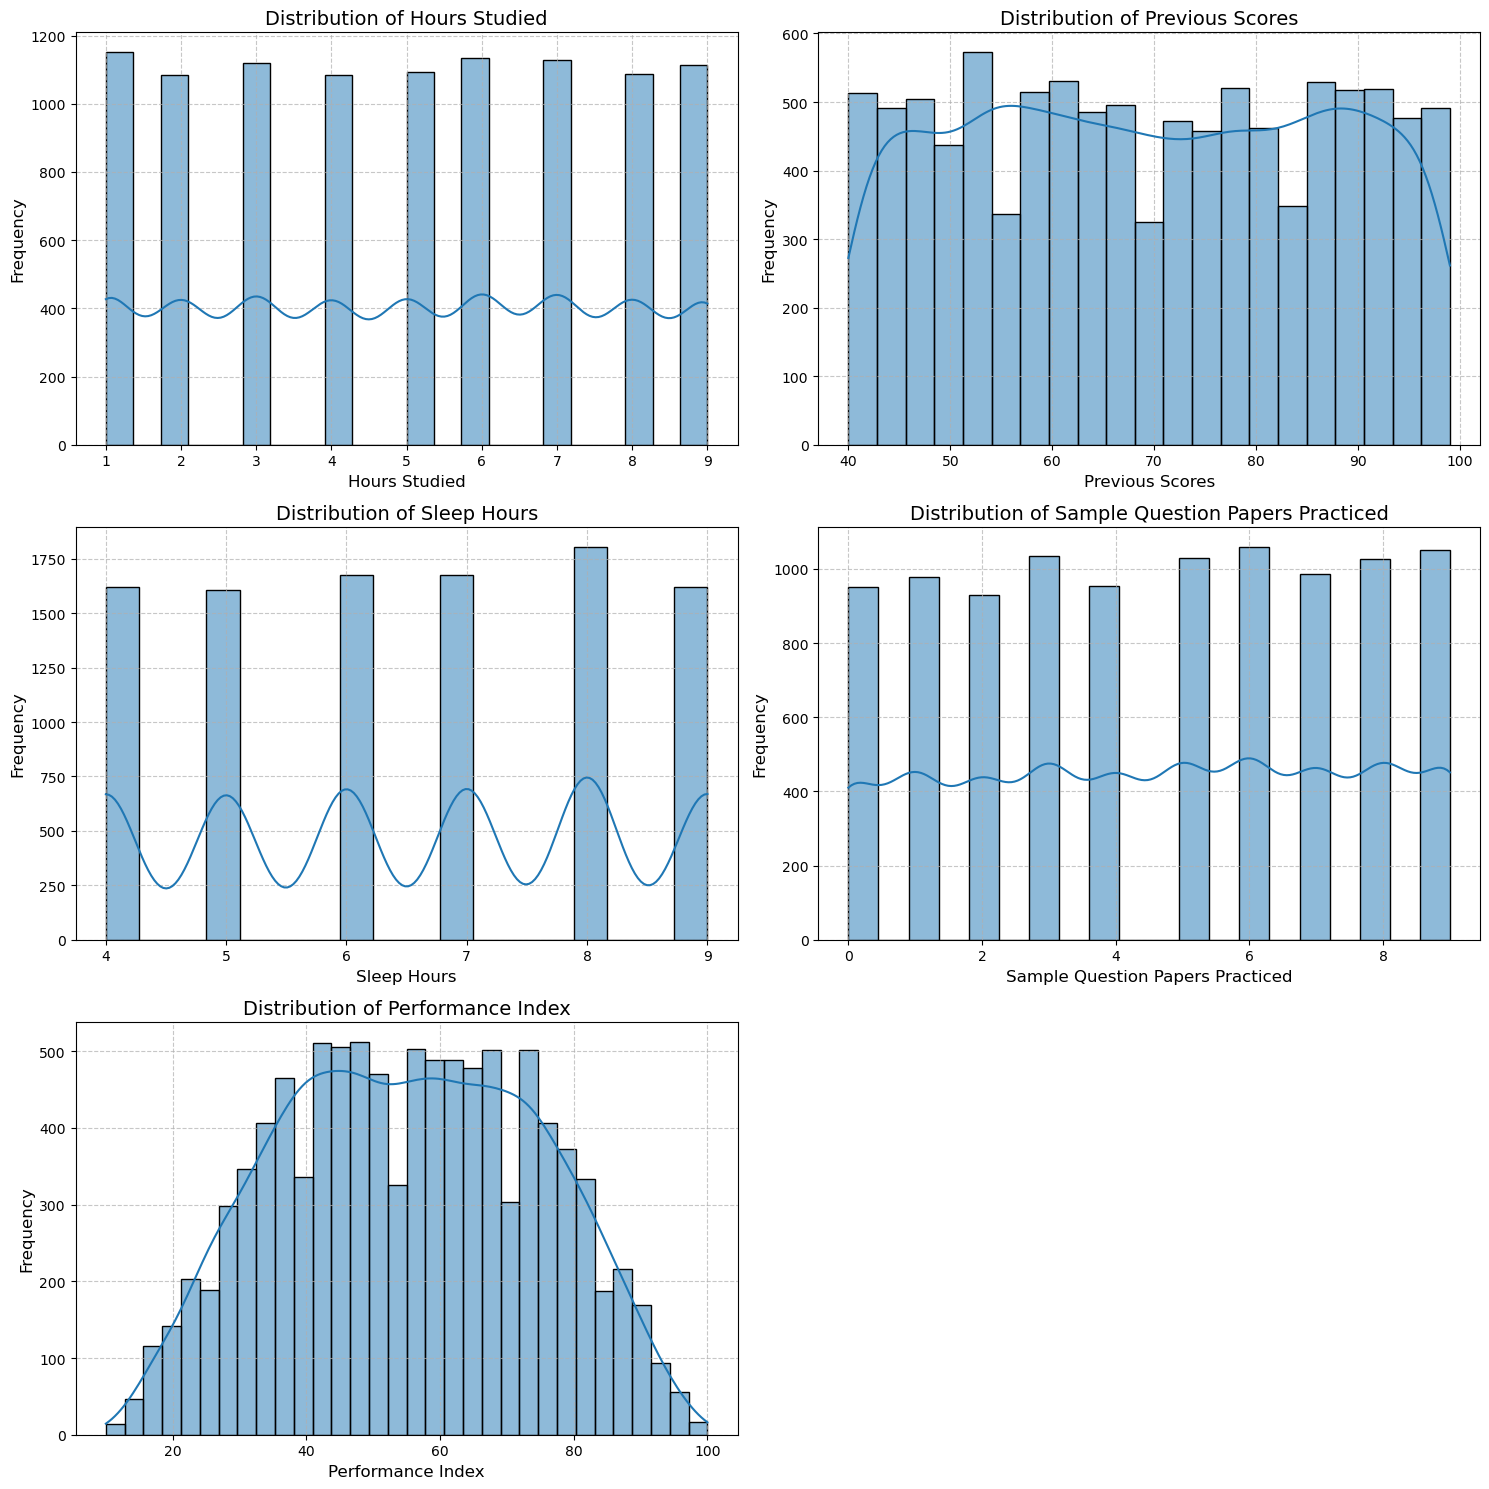

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_plots = len(numerical_cols)
num_rows = (num_plots + 1) // 2  
plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 2, i + 1) 
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

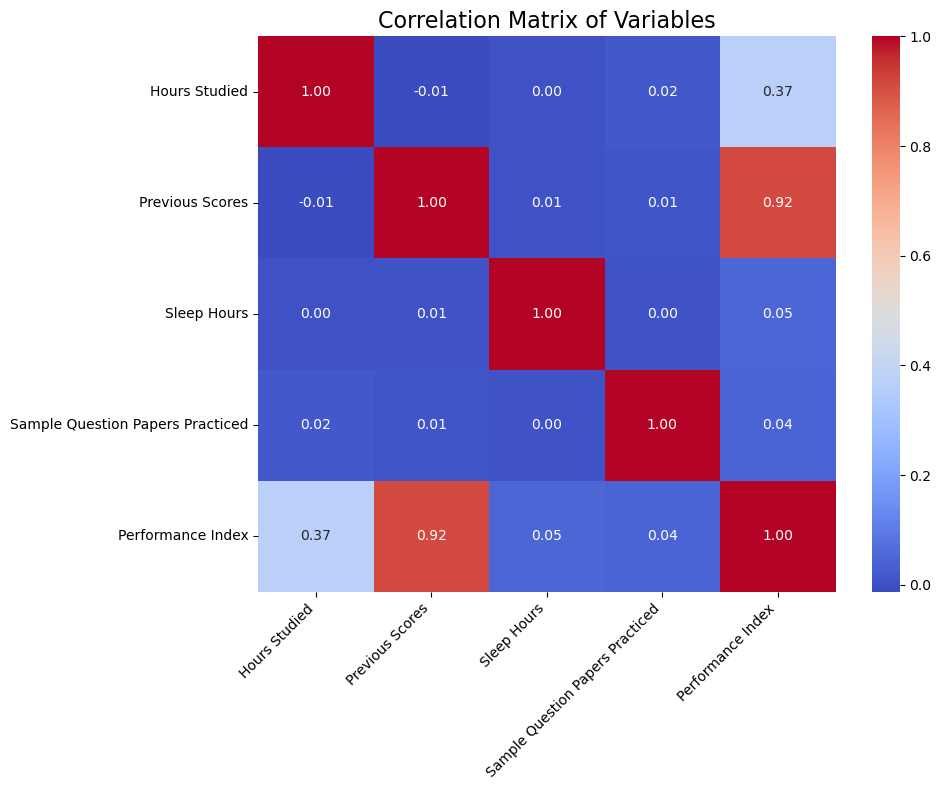

In [13]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
df = pd.get_dummies(df, columns=['Extracurricular Activities'], drop_first=True)
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91.0,True
1,4,82,4,2,65.0,False
2,8,51,7,2,45.0,True
3,5,52,5,2,36.0,True
4,7,75,8,5,66.0,False


In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 5)
Shape of X_test: (2000, 5)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [20]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r_squared = r2_score(y_test, y_pred)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.9890


Adjusted R-squared: 0.9890


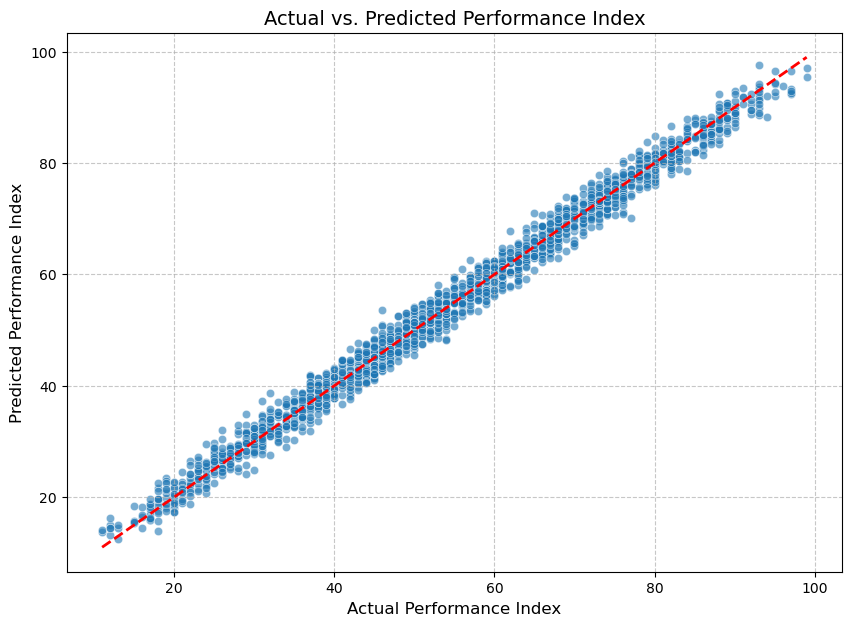

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate adjusted R-squared
n = X_test.shape[0]  # Number of observations in the test set
p = X_test.shape[1]  # Number of predictors (features)

adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
print(f"Adjusted R-squared: {adjusted_r_squared:.4f}")

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Performance Index', fontsize=12)
plt.ylabel('Predicted Performance Index', fontsize=12)
plt.title('Actual vs. Predicted Performance Index', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training features and transform them
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features
X_test_scaled = scaler.transform(X_test)

# Print the shapes to verify
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (8000, 5)
Shape of X_test_scaled: (2000, 5)


In [23]:
from sklearn.linear_model import Ridge

# Instantiate the Ridge regression model
ridge_model = Ridge()

# Fit the model to the scaled training data
ridge_model.fit(X_train_scaled, y_train)

print("Ridge regression model trained successfully.")

Ridge regression model trained successfully.


Ridge R-squared: 0.9890
Ridge Adjusted R-squared: 0.9890


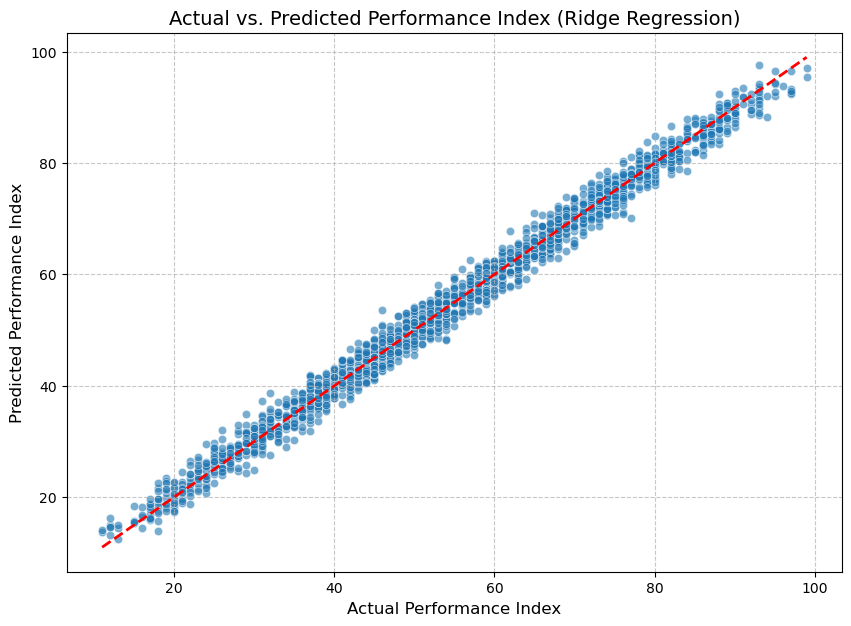

In [24]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make predictions on the scaled test set
y_pred_ridge = ridge_model.predict(X_test_scaled)

# 2. Calculate R-squared
r_squared_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge R-squared: {r_squared_ridge:.4f}")

# 3. Calculate adjusted R-squared
n = X_test_scaled.shape[0]  # Number of observations in the test set
p = X_test_scaled.shape[1]  # Number of predictors (features)

adjusted_r_squared_ridge = 1 - (1 - r_squared_ridge) * (n - 1) / (n - p - 1)
print(f"Ridge Adjusted R-squared: {adjusted_r_squared_ridge:.4f}")

# 4. Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6)

# 5. Add a diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# 6. Label the axes
plt.xlabel('Actual Performance Index', fontsize=12)
plt.ylabel('Predicted Performance Index', fontsize=12)

# 7. Add a title to the plot
plt.title('Actual vs. Predicted Performance Index (Ridge Regression)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# 8. Display the plot
plt.show()

In [25]:
from sklearn.linear_model import Lasso

# Instantiate the Lasso regression model
lasso_model = Lasso()

# Fit the model to the scaled training data
lasso_model.fit(X_train_scaled, y_train)

print("Lasso regression model trained successfully.")

Lasso regression model trained successfully.


Lasso R-squared: 0.9797
Lasso Adjusted R-squared: 0.9797


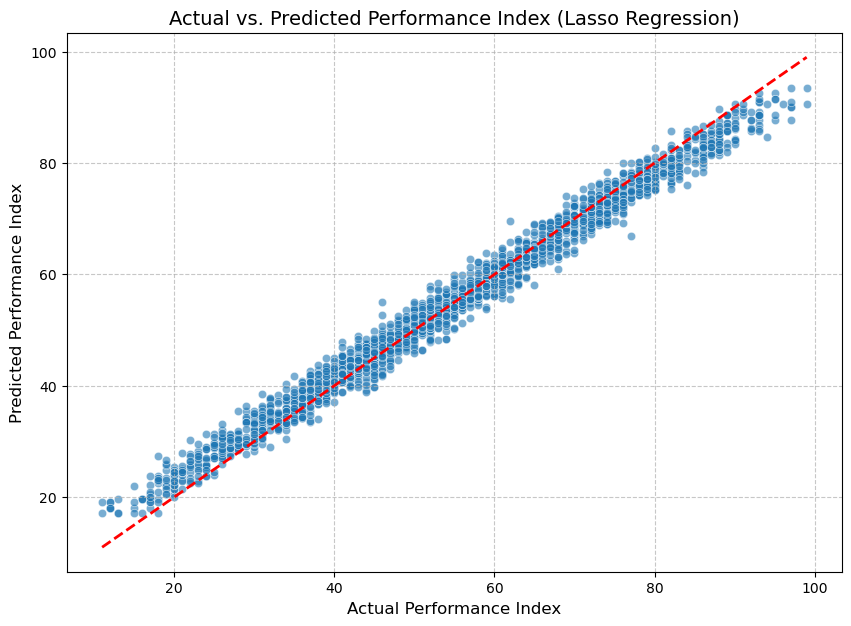

In [26]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make predictions on the scaled test set
y_pred_lasso = lasso_model.predict(X_test_scaled)

# 2. Calculate R-squared
r_squared_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso R-squared: {r_squared_lasso:.4f}")

# 3. Calculate adjusted R-squared
n = X_test_scaled.shape[0]  # Number of observations in the test set
p = X_test_scaled.shape[1]  # Number of predictors (features)

adjusted_r_squared_lasso = 1 - (1 - r_squared_lasso) * (n - 1) / (n - p - 1)
print(f"Lasso Adjusted R-squared: {adjusted_r_squared_lasso:.4f}")

# 4. Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.6)

# 5. Add a diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# 6. Label the axes
plt.xlabel('Actual Performance Index', fontsize=12)
plt.ylabel('Predicted Performance Index', fontsize=12)

# 7. Add a title to the plot
plt.title('Actual vs. Predicted Performance Index (Lasso Regression)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# 8. Display the plot
plt.show()

In [ ]:
                                             # -------    HOUSING    ------ # 

In [27]:
import pandas as pd
df = pd.read_csv('housing1.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [30]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [39]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [40]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [41]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

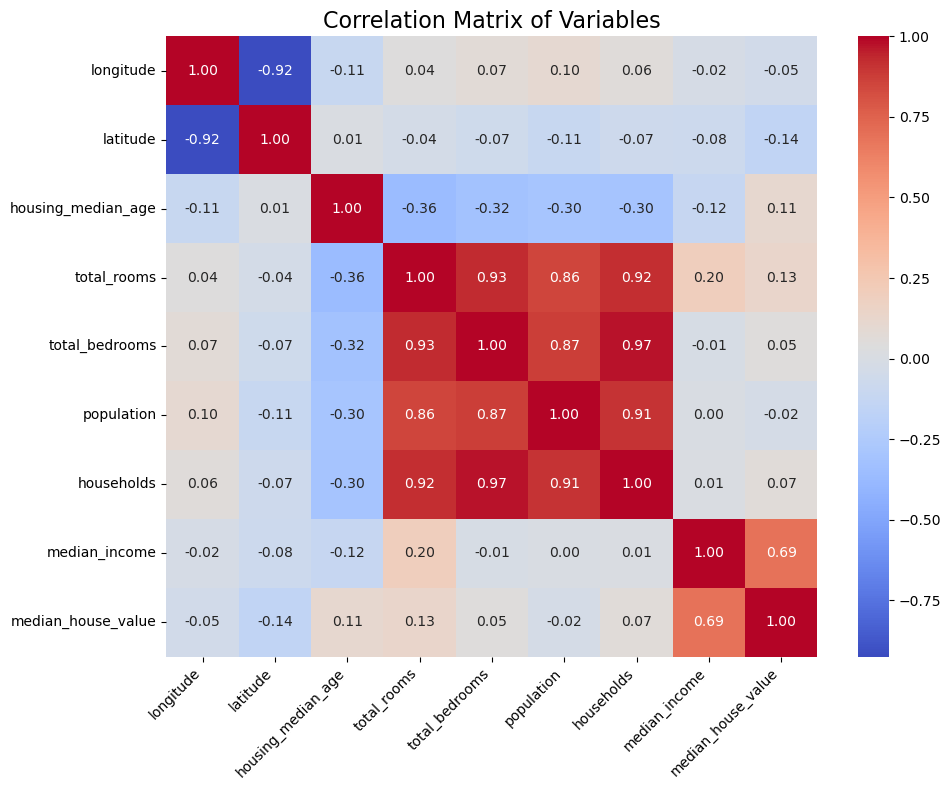

In [42]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [47]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [48]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (16512, 12)
Shape of X_test: (4128, 12)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


In [49]:
from sklearn.linear_model import LinearRegression

# Instantiate the Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [50]:
from sklearn.metrics import r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.6254


Adjusted R-squared: 0.6243


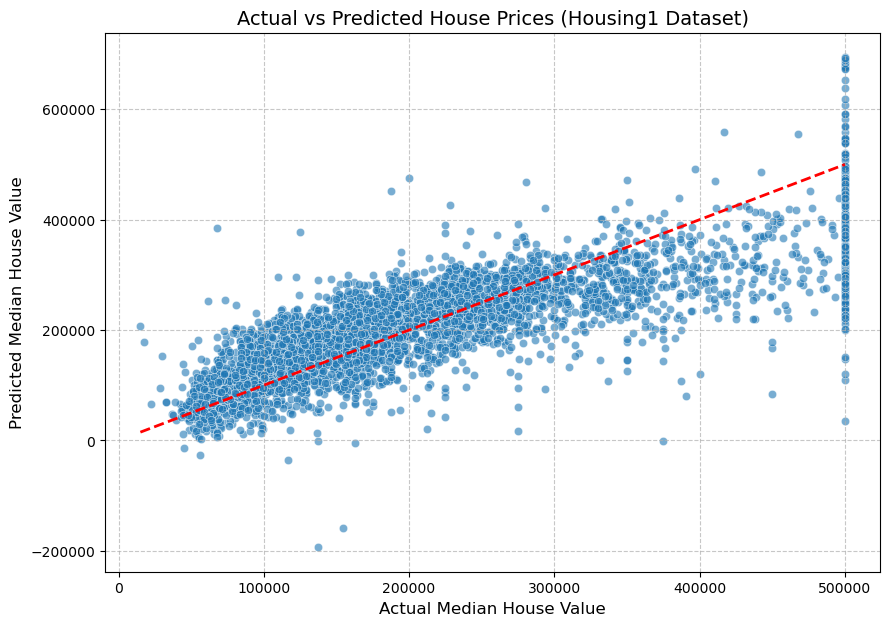

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Calculate R2 score
r_squared = r2_score(y_test, y_pred)

# Calculate adjusted R-squared
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of predictors

adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
print(f"Adjusted R-squared: {adjusted_r_squared:.4f}")

# Scatter plot: Actual vs Predicted House Values
plt.figure(figsize=(10,7))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.xlabel('Actual Median House Value', fontsize=12)
plt.ylabel('Predicted Median House Value', fontsize=12)
plt.title('Actual vs Predicted House Prices (Housing1 Dataset)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [53]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training features and transform them
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features
X_test_scaled = scaler.transform(X_test)

# Print the shapes to verify
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (16512, 12)
Shape of X_test_scaled: (4128, 12)


In [54]:
from sklearn.linear_model import Ridge

# Instantiate the Ridge regression model
ridge_model = Ridge()

# Fit the model to the scaled training data
ridge_model.fit(X_train_scaled, y_train)

print("Ridge regression model trained successfully.")

Ridge regression model trained successfully.


Ridge R-squared: 0.6255
Ridge Adjusted R-squared: 0.6244


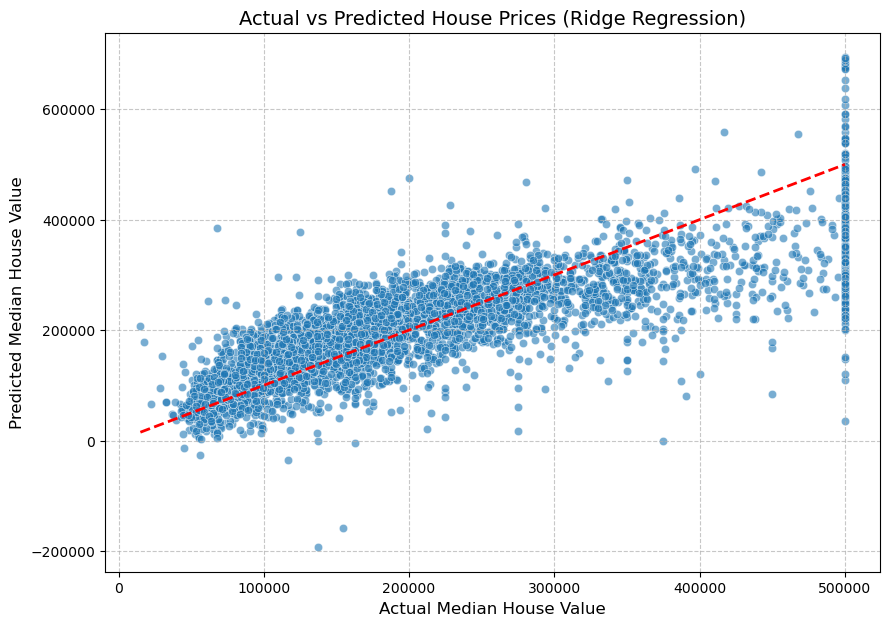

In [55]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make predictions on the scaled test set
y_pred_ridge = ridge_model.predict(X_test_scaled)

# 2. Calculate R-squared
r_squared_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge R-squared: {r_squared_ridge:.4f}")

# 3. Calculate adjusted R-squared
n = X_test_scaled.shape[0]  # number of observations
p = X_test_scaled.shape[1]  # number of predictors

adjusted_r_squared_ridge = 1 - (1 - r_squared_ridge) * (n - 1) / (n - p - 1)
print(f"Ridge Adjusted R-squared: {adjusted_r_squared_ridge:.4f}")

# 4. Scatter plot
plt.figure(figsize=(10,7))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6)

# 5. Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

# 6. Labels
plt.xlabel('Actual Median House Value', fontsize=12)
plt.ylabel('Predicted Median House Value', fontsize=12)

# 7. Title
plt.title('Actual vs Predicted House Prices (Ridge Regression)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [56]:
from sklearn.linear_model import Lasso

# Instantiate the Lasso regression model
lasso_model = Lasso()

# Fit the model to the scaled training data
lasso_model.fit(X_train_scaled, y_train)

print("Lasso regression model trained successfully.")

Lasso regression model trained successfully.


Lasso R-squared: 0.6254
Lasso Adjusted R-squared: 0.6243


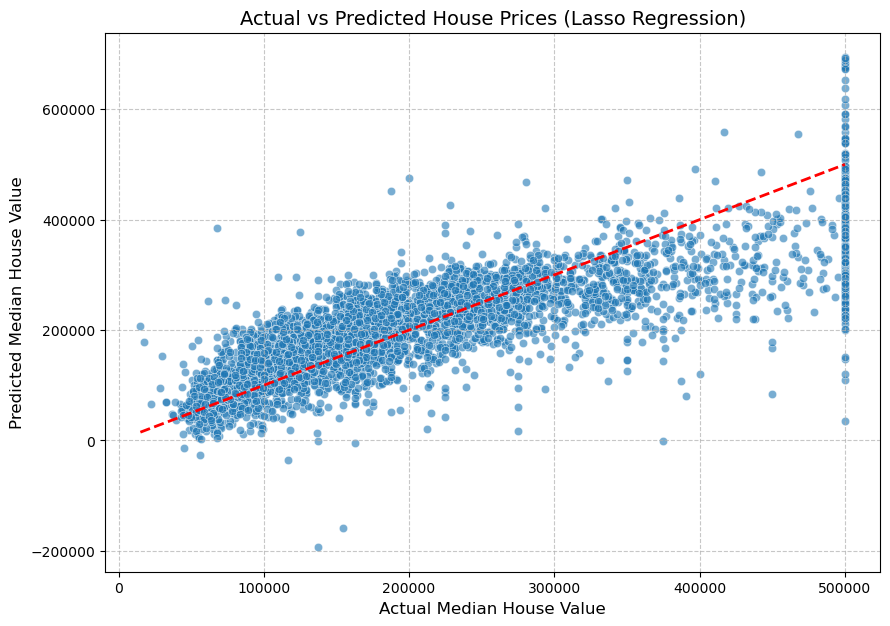

In [57]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make predictions on the scaled test set
y_pred_lasso = lasso_model.predict(X_test_scaled)

# 2. Calculate R-squared
r_squared_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso R-squared: {r_squared_lasso:.4f}")

# 3. Calculate adjusted R-squared
n = X_test_scaled.shape[0]  # number of observations
p = X_test_scaled.shape[1]  # number of predictors

adjusted_r_squared_lasso = 1 - (1 - r_squared_lasso) * (n - 1) / (n - p - 1)
print(f"Lasso Adjusted R-squared: {adjusted_r_squared_lasso:.4f}")

# 4. Scatter plot
plt.figure(figsize=(10,7))
sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.6)

# 5. Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

# 6. Labels
plt.xlabel('Actual Median House Value', fontsize=12)
plt.ylabel('Predicted Median House Value', fontsize=12)

# 7. Title
plt.title('Actual vs Predicted House Prices (Lasso Regression)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
                                                       # ------   AUTO     ------ #

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv('auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [59]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [60]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

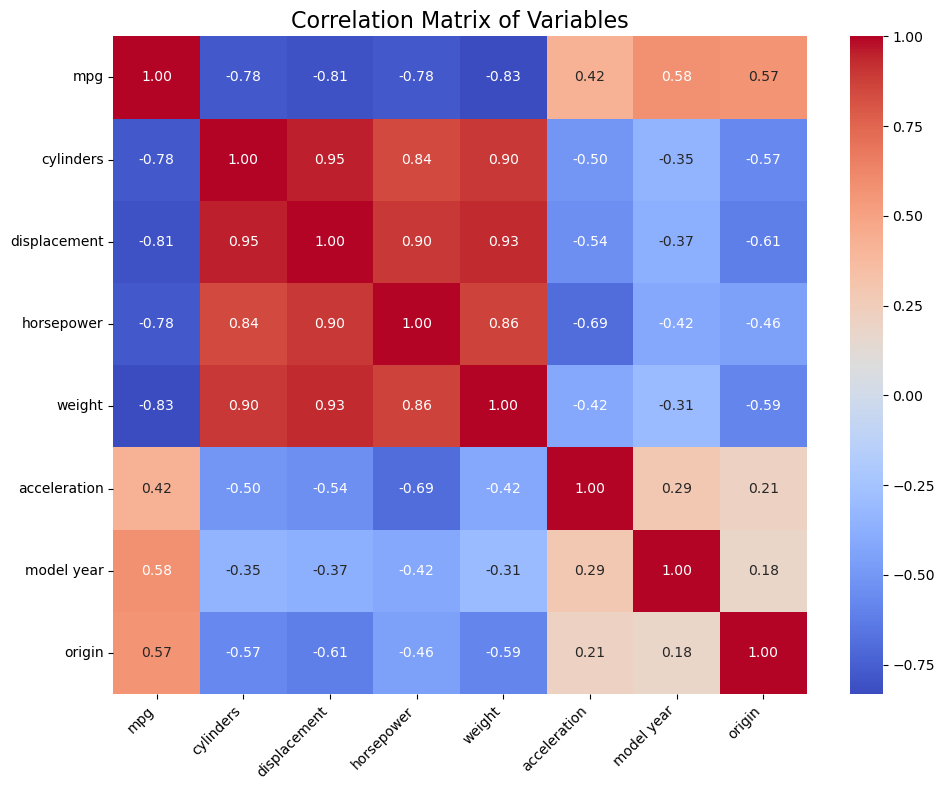

In [76]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df['horsepower'] = df['horsepower'].astype(float)

In [81]:
df.dropna(inplace=True)

X = df[['horsepower']]
y = df['mpg']

In [86]:
X = df[['horsepower']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)



print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (313, 1)
Shape of X_test: (79, 1)
Shape of y_train: (313,)
Shape of y_test: (79,)


In [87]:
y_pred_simple = model_simple.predict(X_test)
print("y_pred shape:", y_pred_simple.shape)

y_pred shape: (79,)


In [83]:
r2_simple = r2_score(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))

print("Simple Linear Regression")
print("R2 Score:", r2_simple)
print("RMSE:", rmse_simple)

Simple Linear Regression
R2 Score: 0.5659681822256184
RMSE: 4.706722545876633


R-squared: 0.5660
Adjusted R-squared: 0.5603


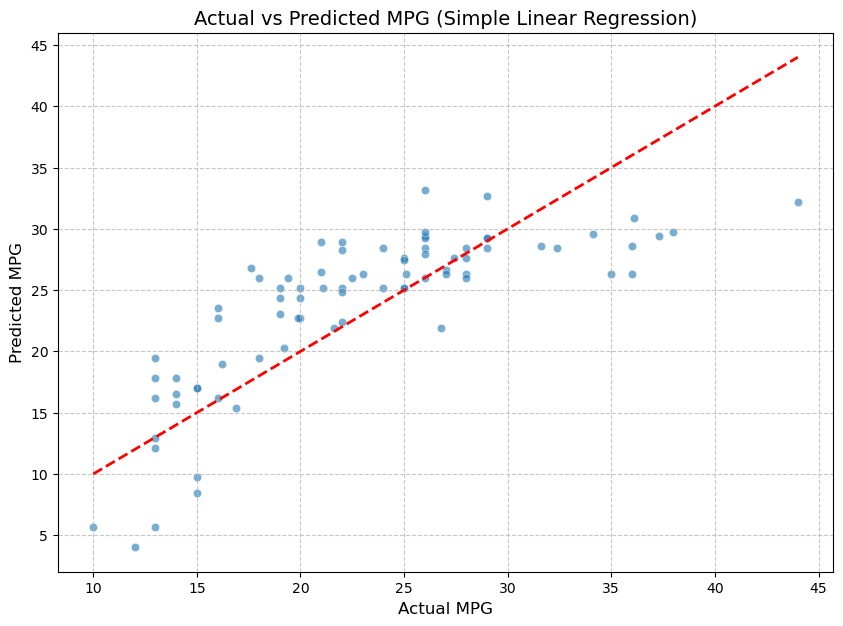

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Calculate R2 score
r_squared = r2_score(y_test, y_pred_simple)

# Calculate adjusted R-squared
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of predictors (here p = 1)

adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print(f"R-squared: {r_squared:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared:.4f}")

# Scatter plot: Actual vs Predicted MPG
plt.figure(figsize=(10,7))

sns.scatterplot(x=y_test, y=y_pred_simple, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.xlabel('Actual MPG', fontsize=12)
plt.ylabel('Predicted MPG', fontsize=12)

plt.title('Actual vs Predicted MPG (Simple Linear Regression)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [91]:
X_multi = df[['cylinders','displacement','horsepower',
              'weight','acceleration','model year']]

y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (313, 6)
Shape of X_test: (79, 6)
Shape of y_train: (313,)
Shape of y_test: (79,)


In [92]:
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("Multiple Linear Regression")
print("R2 Score:", r2_multi)
print("RMSE:", rmse_multi)

Multiple Linear Regression
R2 Score: 0.7942349075428586
RMSE: 3.2407360783342605


In [ ]:
# Simple Linear Regression predicts MPG using only horsepower.
# Multiple Linear Regression uses several car features, giving better prediction accuracy.
# The multiple regression model shows higher R² and lower RMSE, indicating better performance.

In [93]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training features and transform them
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features
X_test_scaled = scaler.transform(X_test)

# Print the shapes to verify
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (313, 6)
Shape of X_test_scaled: (79, 6)


In [94]:
from sklearn.linear_model import Ridge

# Instantiate the Ridge regression model
ridge_model = Ridge()

# Fit the model to the scaled training data
ridge_model.fit(X_train_scaled, y_train)

print("Ridge regression model trained successfully.")

Ridge regression model trained successfully.


Ridge R-squared: 0.7936
Ridge Adjusted R-squared: 0.7764


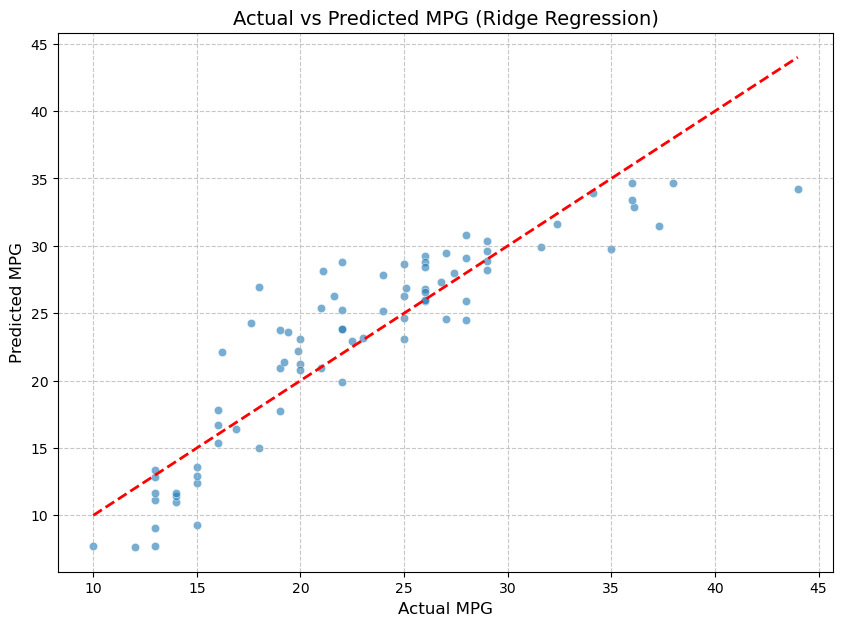

In [95]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make predictions on the scaled test set
y_pred_ridge = ridge_model.predict(X_test_scaled)

# 2. Calculate R-squared
r_squared_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge R-squared: {r_squared_ridge:.4f}")

# 3. Calculate adjusted R-squared
n = X_test_scaled.shape[0]  # number of observations
p = X_test_scaled.shape[1]  # number of predictors

adjusted_r_squared_ridge = 1 - (1 - r_squared_ridge) * (n - 1) / (n - p - 1)
print(f"Ridge Adjusted R-squared: {adjusted_r_squared_ridge:.4f}")

# 4. Scatter plot: Actual vs Predicted MPG
plt.figure(figsize=(10,7))

sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6)

# 5. Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

# 6. Labels
plt.xlabel('Actual MPG', fontsize=12)
plt.ylabel('Predicted MPG', fontsize=12)

# 7. Title
plt.title('Actual vs Predicted MPG (Ridge Regression)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [96]:
from sklearn.linear_model import Lasso

# Instantiate the Lasso regression model
lasso_model = Lasso()

# Fit the model to the scaled training data
lasso_model.fit(X_train_scaled, y_train)

print("Lasso regression model trained successfully.")

Lasso regression model trained successfully.


Lasso R-squared: 0.8019
Lasso Adjusted R-squared: 0.7854


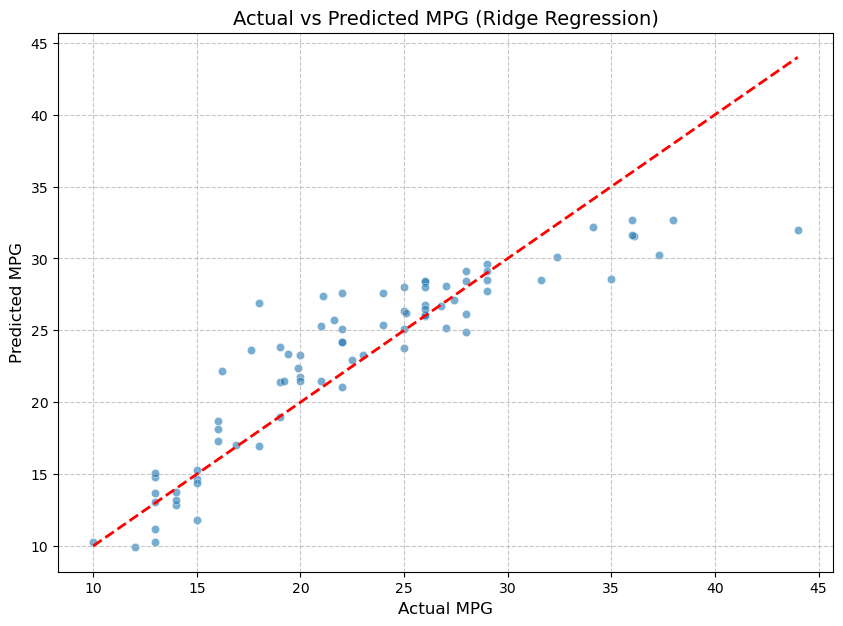

In [97]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make predictions on the scaled test set
y_pred_lasso = lasso_model.predict(X_test_scaled)

# 2. Calculate R-squared
r_squared_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso R-squared: {r_squared_lasso:.4f}")

# 3. Calculate adjusted R-squared
n = X_test_scaled.shape[0]  # number of observations
p = X_test_scaled.shape[1]  # number of predictors

adjusted_r_squared_lasso = 1 - (1 - r_squared_lasso) * (n - 1) / (n - p - 1)
print(f"Lasso Adjusted R-squared: {adjusted_r_squared_lasso:.4f}")

# 4. Scatter plot: Actual vs Predicted MPG
plt.figure(figsize=(10,7))

sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.6)

# 5. Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

# 6. Labels
plt.xlabel('Actual MPG', fontsize=12)
plt.ylabel('Predicted MPG', fontsize=12)

# 7. Title
plt.title('Actual vs Predicted MPG (Ridge Regression)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
                                                # ------- LIFE EXPECTANCY DATA ------- #

In [102]:
df = pd.read_csv('Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [103]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [104]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [105]:
df.columns = df.columns.str.strip()

In [106]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [107]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [108]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

In [109]:
df['Status'] = df['Status'].map({'Developed':1, 'Developing':0})

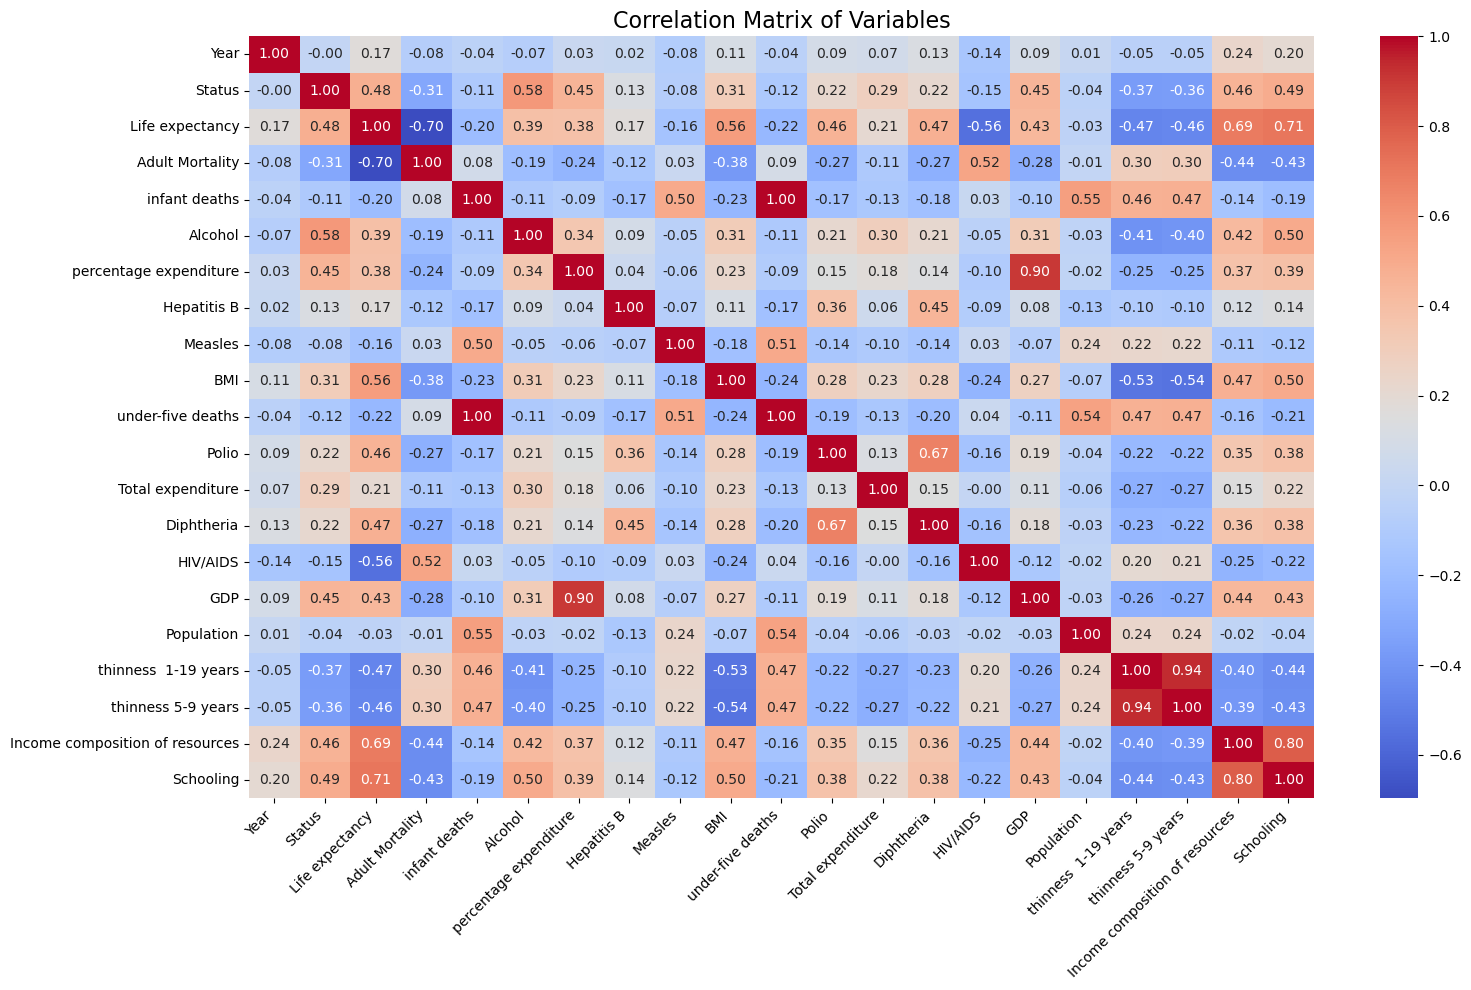

In [118]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [111]:
y = df['Life expectancy']
print(y)

0       65.0
1       59.9
2       59.9
3       59.5
4       59.2
        ... 
2933    44.3
2934    44.5
2935    44.8
2936    45.3
2937    46.0
Name: Life expectancy, Length: 2938, dtype: float64


In [112]:
X = df.drop(['Life expectancy','Country','Year'], axis=1)

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (2350, 19)
Shape of X_test: (588, 19)
Shape of y_train: (2350,)
Shape of y_test: (588,)


In [120]:
from sklearn.linear_model import LinearRegression

# Instantiate the Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [121]:
from sklearn.metrics import r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.8235


In [122]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.8235482778191813
Linear Regression RMSE: 3.9105761551126075


In [115]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

R-squared: 0.8235
Adjusted R-squared: 0.8176


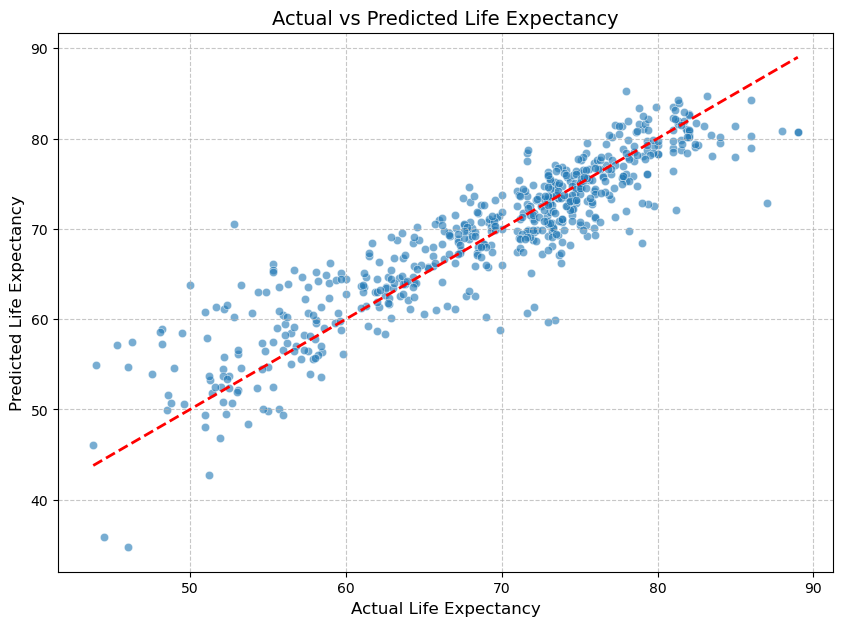

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Calculate R2 score
r_squared = r2_score(y_test, y_pred)

# Calculate adjusted R-squared
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of predictors

adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print(f"R-squared: {r_squared:.4f}")
print(f"Adjusted R-squared: {adjusted_r_squared:.4f}")

# Scatter plot
plt.figure(figsize=(10,7))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.xlabel('Actual Life Expectancy', fontsize=12)
plt.ylabel('Predicted Life Expectancy', fontsize=12)

plt.title('Actual vs Predicted Life Expectancy', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [124]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge R2: 0.8231343952254253
Ridge RMSE: 3.9151597641579996


Ridge R-squared: 0.8231
Ridge Adjusted R-squared: 0.8172


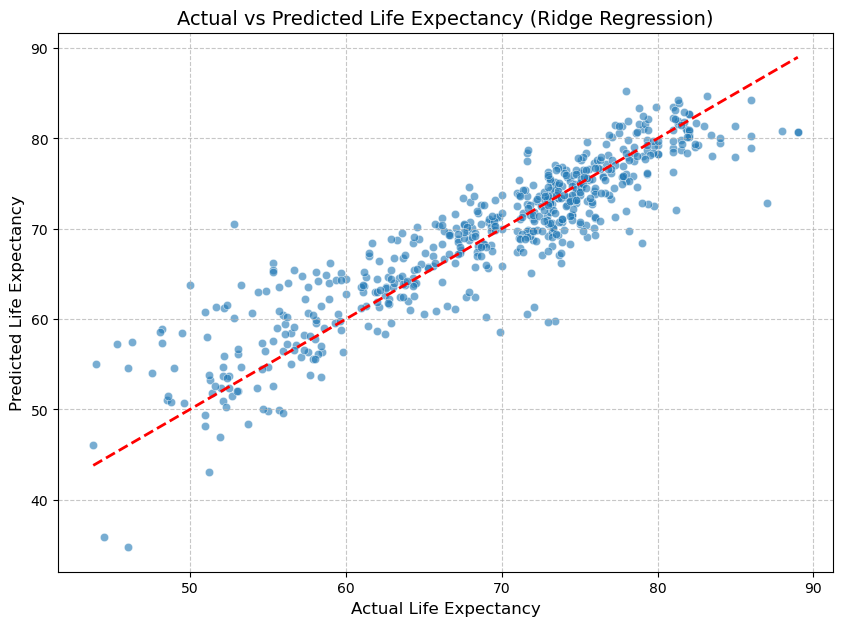

In [127]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make predictions on the scaled test set
y_pred_ridge = ridge.predict(X_test_scaled)

# 2. Calculate R-squared
r_squared_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge R-squared: {r_squared_ridge:.4f}")

# 3. Calculate adjusted R-squared
n = X_test_scaled.shape[0]  # number of observations
p = X_test_scaled.shape[1]  # number of predictors

adjusted_r_squared_ridge = 1 - (1 - r_squared_ridge) * (n - 1) / (n - p - 1)
print(f"Ridge Adjusted R-squared: {adjusted_r_squared_ridge:.4f}")

# 4. Scatter plot: Actual vs Predicted 
plt.figure(figsize=(10,7))

sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6)

# 5. Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

# 6. Labels
plt.xlabel('Actual Life Expectancy', fontsize=12)
plt.ylabel('Predicted Life Expectancy', fontsize=12)

# 7. Title
plt.title('Actual vs Predicted Life Expectancy (Ridge Regression)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [125]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso R2: 0.8109942357330391
Lasso RMSE: 4.047299299096732


Lasso R-squared: 0.8110
Lasso Adjusted R-squared: 0.8047


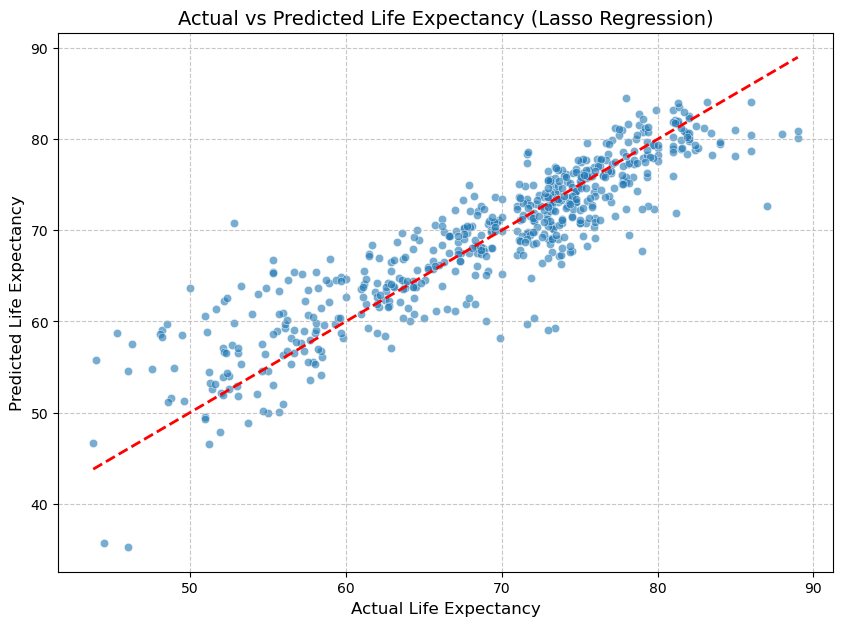

In [128]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Make predictions on the scaled test set
y_pred_lasso = lasso.predict(X_test_scaled)

# 2. Calculate R-squared
r_squared_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso R-squared: {r_squared_lasso:.4f}")

# 3. Calculate adjusted R-squared
n = X_test_scaled.shape[0]  # number of observations
p = X_test_scaled.shape[1]  # number of predictors

adjusted_r_squared_lasso = 1 - (1 - r_squared_lasso) * (n - 1) / (n - p - 1)
print(f"Lasso Adjusted R-squared: {adjusted_r_squared_lasso:.4f}")

# 4. Scatter plot: Actual vs Predicted 
plt.figure(figsize=(10,7))

sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.6)

# 5. Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

# 6. Labels
plt.xlabel('Actual Life Expectancy', fontsize=12)
plt.ylabel('Predicted Life Expectancy', fontsize=12)

# 7. Title
plt.title('Actual vs Predicted Life Expectancy (Lasso Regression)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()